In [103]:
import random
import numpy as np
import pandas as pd
from pandas import DataFrame
from datetime import datetime, timedelta

# 1. Reproducibility Seed
random.seed(42)
np.random.seed(42)

# 2. Configuration Settings
n_transactions = 100000
fraud_count = 3000
start = datetime(2025, 1, 1)
fraud_indices = set(random.sample(range(n_transactions), fraud_count))

# 3. Base Feature Pools
customers = [f"CUST{str(i).zfill(5)}" for i in range(1, 5001)]
devices = ["Android", "iPhone", "Windows", "Mac", "Linux"]
card_types = ["Visa", "MasterCard", "RuPay", "Amex"]
cities = [
    "Delhi","Mumbai","Bengaluru","Hyderabad","Chennai","Kolkata","Pune","Ahmedabad",
    "Jaipur","Lucknow","Kanpur","Nagpur","Indore","Bhopal","Patna","Surat","Vadodara",
    "Chandigarh","Ludhiana","Agra","Varanasi","Noida","Gurugram","Faridabad","Kochi",
    "Thiruvananthapuram","Visakhapatnam","Coimbatore","Mysuru","Nashik","Rajkot",
    "Jodhpur","Amritsar","Dehradun","Raipur","Ranchi","Guwahati","Shimla","Srinagar",
    "Jammu","Aurangabad","Gwalior","Udaipur","Meerut","Aligarh","Madurai","Salem",
    "Tiruchirappalli","Hubballi","Vijayawada"
]

# Split merchants into High-Risk (e.g., luxury, crypto, gift cards) and Low-Risk pools
all_merchants = [f"MER{str(i).zfill(4)}" for i in range(1, 501)]
high_risk_merchants = all_merchants[:25]   # 5% of merchants are inherently high-risk
normal_merchants = all_merchants[25:]

# 4. Hourly Probability Distributions (24 hours)
hours_pool = list(range(24))
normal_hour_weights = [5, 2, 1, 1, 1, 2, 5, 10, 15, 20, 25, 30, 35, 35, 30, 25, 30, 35, 30, 25, 20, 15, 10, 8]
fraud_hour_weights  = [35, 40, 35, 30, 25, 15, 10, 5, 5, 5, 8, 10, 12, 12, 10, 8, 10, 12, 15, 18, 20, 22, 25, 30]

# 5. Generate Complex Correlated Rows
rows = []
for i in range(n_transactions):
    fraud = 1 if i in fraud_indices else 0

    if fraud:
        # REAL-WORLD RULE 1: Fraud targets high-risk merchants 65% of the time
        merchant = random.choice(high_risk_merchants) if random.random() < 0.65 else random.choice(normal_merchants)
        
        # REAL-WORLD RULE 2: Fraud prefers specific card types (Amex/Visa) and emulators/operating systems (Linux/Android)
        card = random.choices(card_types, weights=[40, 20, 10, 30])[0]
        device = random.choices(devices, weights=[35, 15, 10, 10, 30])[0]
        
        # REAL-WORLD RULE 3: Fraud amounts are highly volatile and log-normally distributed (mostly large, some tiny test charges)
        amount = round(np.random.lognormal(mean=8.5, sigma=1.2), 2)
        amount = max(5.0, min(amount, 125000.0))  # Bound to realistic ranges
        
        prev_fraud = random.choices([0, 1], weights=[55, 45])[0]
        hour = random.choices(hours_pool, weights=fraud_hour_weights)[0]
    else:
        # Normal behavior patterns
        merchant = random.choice(high_risk_merchants) if random.random() < 0.04 else random.choice(normal_merchants)
        card = random.choices(card_types, weights=[30, 30, 25, 15])[0]
        device = random.choices(devices, weights=[25, 35, 25, 12, 3])[0]
        
        # Normal amounts follow a steady, lower-value log-normal distribution
        amount = round(np.random.lognormal(mean=6.8, sigma=0.8), 2)
        amount = max(10.0, min(amount, 35000.0))
        
        prev_fraud = random.choices([0, 1], weights=[98, 2])[0]
        hour = random.choices(hours_pool, weights=normal_hour_weights)[0]

    # Map the chosen hour into a realistic date timestamp
    dt = start + timedelta(days=random.randint(0, 364),
                           hours=hour,
                           minutes=random.randint(0, 59),
                           seconds=random.randint(0, 59))

    rows.append({
        "Transaction_ID": f"TXN{str(i+1).zfill(7)}",
        "Customer_ID": random.choice(customers),
        "Amount": amount,
        "Merchant": merchant,
        "Time": dt.strftime("%Y-%m-%d %H:%M:%S"),
        "Location": random.choice(cities),
        "Device": device,
        "Previous_Fraud": prev_fraud,
        "Card_Type": card,
        "Label": fraud
    })

# 6. Save directly to CSV
df = DataFrame(rows)
csv_path = "fraud_dataset.csv"
df.to_csv(csv_path, index=False)

print(f"Dataset successfully created and saved to: {csv_path}\n")
print("--- FIRST 5 ROWS ---")
print(df.head())

Dataset successfully created and saved to: fraud_dataset.csv

--- FIRST 5 ROWS ---
  Transaction_ID Customer_ID   Amount Merchant                 Time  Location  \
0     TXN0000001   CUST04720  1335.91  MER0145  2025-05-29 09:14:52  Varanasi   
1     TXN0000002   CUST03388   803.83  MER0421  2025-12-05 09:33:14      Agra   
2     TXN0000003   CUST00385  1507.41  MER0311  2025-08-07 16:35:31  Gurugram   
3     TXN0000004   CUST04407  3036.39  MER0369  2025-06-03 13:24:11    Rajkot   
4     TXN0000005   CUST04566   744.47  MER0141  2025-10-15 20:26:26  Dehradun   

    Device  Previous_Fraud   Card_Type  Label  
0  Windows               0  MasterCard      0  
1   iPhone               0       RuPay      0  
2      Mac               0        Amex      0  
3   iPhone               0  MasterCard      0  
4  Windows               0  MasterCard      0  


In [104]:
import pandas as pd 

In [105]:
df = pd.read_csv('fraud_dataset.csv')

In [106]:
df.head()

,Transaction_ID,Customer_ID,Amount,Merchant,Time,Location,Device,Previous_Fraud,Card_Type,Label
0,TXN0000001,CUST04720,1335.91,MER0145,2025-05-29 09:14:52,Varanasi,Windows,0,MasterCard,0
1,TXN0000002,CUST03388,803.83,MER0421,2025-12-05 09:33:14,Agra,iPhone,0,RuPay,0
2,TXN0000003,CUST00385,1507.41,MER0311,2025-08-07 16:35:31,Gurugram,Mac,0,Amex,0
3,TXN0000004,CUST04407,3036.39,MER0369,2025-06-03 13:24:11,Rajkot,iPhone,0,MasterCard,0
4,TXN0000005,CUST04566,744.47,MER0141,2025-10-15 20:26:26,Dehradun,Windows,0,MasterCard,0


In [107]:

df['Time'] = pd.to_datetime(df['Time'])


df['Date'] = df['Time'].dt.date
df['Time'] = df['Time'].dt.time

In [108]:
# Assuming you already converted them to datetime objects
df['Month'] = pd.to_datetime(df['Date']).dt.month
df['Day_of_Week'] = pd.to_datetime(df['Date']).dt.dayofweek
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.hour

In [109]:
X = df.drop(columns=["Label","Transaction_ID","Customer_ID"])
y=df["Label"]

In [110]:
from sklearn.model_selection import train_test_split

In [111]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [112]:
from sklearn.ensemble import RandomForestClassifier 
from sklearn.pipeline import Pipeline

In [113]:
categorical_features = [
    "Merchant",
    "Location",
    "Device",
    "Card_Type",
    "Day_of_Week"
]

numerical_features = [
    "Amount",
    "Previous_Fraud",
    "Month",       
    "Hour"         #
]

In [114]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler

In [115]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features),
        ("num", StandardScaler(), numerical_features)
    ]
)

In [116]:
rf_model = Pipeline([
    ("preprocessor",preprocessor),
    ("classifier",RandomForestClassifier(
        n_estimators=50,
        random_state=42
    ))
])

In [117]:
rf_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Amount','Merchant','Time',...,'Month','Day_of_Week','Hour']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remai

In [118]:
rf_preds = rf_model.predict(X_test)

In [119]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, rf_preds))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_preds))

print("\nClassification Report:")
print(classification_report(y_test, rf_preds))

Accuracy: 0.9866666666666667

Confusion Matrix:
[[29095    35]
 [  365   505]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     29130
           1       0.94      0.58      0.72       870

    accuracy                           0.99     30000
   macro avg       0.96      0.79      0.85     30000
weighted avg       0.99      0.99      0.99     30000



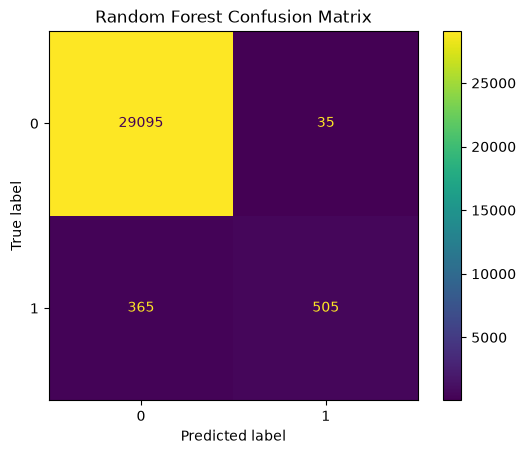

In [120]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

In [129]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=50,
        max_depth=6,
        scale_pos_weight=33,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    ))
])


In [131]:
xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Amount','Merchant','Time',...,'Month','Day_of_Week','Hour']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remai

In [132]:
xgb_preds = xgb_model.predict(X_test)

In [134]:
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

custom_preds = (xgb_probs >= 0.25).astype(int)

print(classification_report(y_test, custom_preds))

              precision    recall  f1-score   support

           0       1.00      0.86      0.92     29130
           1       0.17      0.95      0.29       870

    accuracy                           0.86     30000
   macro avg       0.58      0.90      0.61     30000
weighted avg       0.97      0.86      0.91     30000



In [136]:
from sklearn.metrics import f1_score

# Get the probability scores for the fraud class
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# Test thresholds from 0.1 to 0.9
# Test the higher threshold spectrum to find the peak
for thresh in [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]:
    preds = (xgb_probs >= thresh).astype(int)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"Threshold: {thresh:.2f} | Fraud F1-Score: {f1:.4f}")

Threshold: 0.60 | Fraud F1-Score: 0.5541
Threshold: 0.65 | Fraud F1-Score: 0.6010
Threshold: 0.70 | Fraud F1-Score: 0.6502
Threshold: 0.75 | Fraud F1-Score: 0.6807
Threshold: 0.80 | Fraud F1-Score: 0.7097
Threshold: 0.85 | Fraud F1-Score: 0.7349
Threshold: 0.90 | Fraud F1-Score: 0.7035


In [137]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Apply the optimal threshold
optimal_thresh = 0.85
final_preds = (xgb_probs >= optimal_thresh).astype(int)

# 2. Print the final balanced results
print(f"Final Accuracy: {accuracy_score(y_test, final_preds):.4f}")
print("\n--- Final Confusion Matrix ---")
print(confusion_matrix(y_test, final_preds))

print("\n--- Final Classification Report ---")
print(classification_report(y_test, final_preds))

Final Accuracy: 0.9855

--- Final Confusion Matrix ---
[[28962   168]
 [  267   603]]

--- Final Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     29130
           1       0.78      0.69      0.73       870

    accuracy                           0.99     30000
   macro avg       0.89      0.84      0.86     30000
weighted avg       0.98      0.99      0.99     30000



In [124]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, xgb_preds))
print(confusion_matrix(y_test, xgb_preds))
print(classification_report(y_test, xgb_preds))

Accuracy: 0.9861666666666666
[[29069    61]
 [  354   516]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     29130
           1       0.89      0.59      0.71       870

    accuracy                           0.99     30000
   macro avg       0.94      0.80      0.85     30000
weighted avg       0.99      0.99      0.98     30000



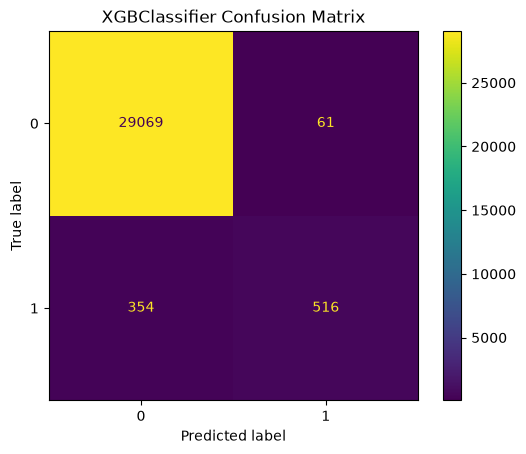

In [125]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, xgb_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("XGBClassifier Confusion Matrix")
plt.show()

In [126]:
from sklearn.metrics import classification_report

print(classification_report(y_test,xgb_preds
                            ))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     29130
           1       0.89      0.59      0.71       870

    accuracy                           0.99     30000
   macro avg       0.94      0.80      0.85     30000
weighted avg       0.99      0.99      0.98     30000



In [127]:
import pickle


with open('model.pkl', 'wb') as file:
    pickle.dump(xgb_model, file)